In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [55]:
data_iris = pd.read_csv('../data/Iris.csv')

data_iris

X = data_iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = data_iris['Species']

/tmp/ipykernel_8960/1594398363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=data_iris, palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

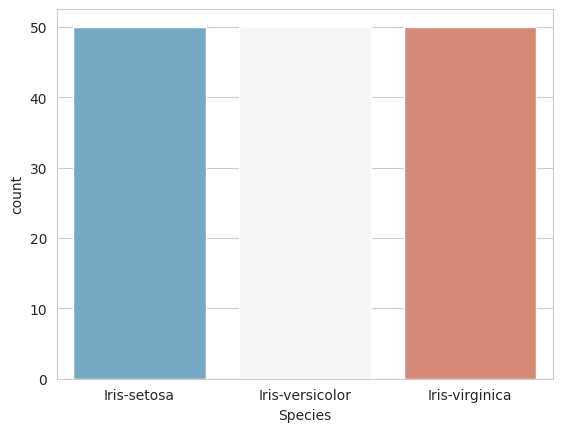

In [56]:
sns.set_style("whitegrid")
sns.countplot(x='Species', data=data_iris, palette='RdBu_r')

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [59]:
# Logistic adalah sigmoid dalam sklearn
activation = ['logistic', 'tanh', 'relu']

results = []

for act in activation:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        max_iter=1000,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    results.append({
        'Activation': act,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
        'Epoch' : model.n_iter_
    })

/home/sevti/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/sevti/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [60]:
results_df = pd.DataFrame(results)

print(results_df)

  Activation  Accuracy  Precision    Recall  F1-Score  Epoch
0   logistic  0.966667   0.969697  0.966667  0.966583   1000
1       tanh  0.966667   0.969697  0.966667  0.966583   1000
2       relu  0.966667   0.969697  0.966667  0.966583    947


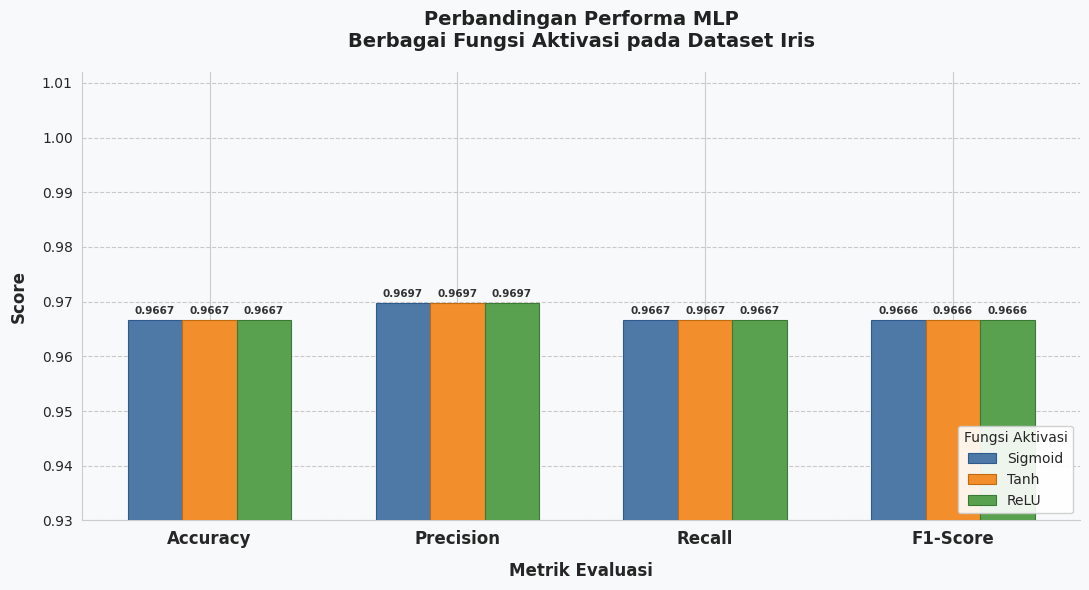

In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
activations = results_df['Activation'].tolist()
label_map = {'logistic': 'Sigmoid', 'tanh': 'Tanh', 'relu': 'ReLU'}
activation_labels = [label_map[a] for a in activations]

x = np.arange(len(metrics))
width = 0.22
n = len(activations)

colors = ['#4E79A7', '#F28E2B', '#59A14F']
edge_colors = ['#2E5B8E', '#C06B10', '#3A7A35']

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

for i, (act, label, color, edge) in enumerate(zip(activations, activation_labels, colors, edge_colors)):
    vals = [results_df.loc[results_df['Activation'] == act, m].values[0] for m in metrics]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width=width,
                  label=label, color=color, edgecolor=edge,
                  linewidth=0.8, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0008,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=7.5,
                fontweight='bold', color='#333333', rotation=0)

ax.set_ylim(0.93, 1.012)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlabel('Metrik Evaluasi', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Perbandingan Performa MLP\nBerbagai Fungsi Aktivasi pada Dataset Iris',
             fontsize=14, fontweight='bold', pad=18, color='#222222')

ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#AAAAAA', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

legend = ax.legend(title='Fungsi Aktivasi', title_fontsize=10,
                   fontsize=10, framealpha=0.9,
                   edgecolor='#CCCCCC', loc='lower right')
legend.get_frame().set_facecolor('#FFFFFF')

plt.tight_layout()
# Download gambarnya
plt.savefig('mlp_comparison.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


## Catatan & Kesimpulan: Fungsi Aktivasi Terbaik untuk Dataset Iris

Berdasarkan hasil eksperimen MLP pada dataset Iris:

| Fungsi Aktivasi | Accuracy | Precision | Recall | F1-Score | Konvergensi |
|---|---|---|---|---|---|
| **Sigmoid** | 0.9667 | 0.9697 | 0.9667 | 0.9666 | Belum konvergen (>1000 iter) |
| **Tanh** | 0.9667 | 0.9697 | 0.9667 | 0.9666 | Belum konvergen (>1000 iter) |
| **ReLU** | 0.9667 | 0.9697 | 0.9667 | 0.9666 | Konvergen di iter ke-947 |

### Fungsi Aktivasi Terbaik: **ReLU**

**Alasan:**
- Ketiga fungsi aktivasi menghasilkan skor evaluasi yang **identik** pada dataset Iris (Accuracy, Precision, Recall, dan F1-Score sama persis).
- Perbedaan yang dapat diamati adalah **kecepatan konvergensi**: ReLU berhasil konvergen pada iterasi ke-948, sedangkan Sigmoid dan Tanh **belum konvergen** bahkan setelah 1000 iterasi penuh (terdapat `ConvergenceWarning`).
- Karena performa metrik sama, **ReLU unggul** karena lebih efisien secara komputasi — membutuhkan lebih sedikit iterasi untuk mencapai hasil yang setara.

> **Kesimpulan:** Untuk dataset Iris dengan konfigurasi ini (1 hidden layer, 10 neuron), **ReLU adalah fungsi aktivasi terbaik** bukan karena akurasinya lebih tinggi, melainkan karena proses pelatihannya **lebih cepat dan efisien** dibandingkan Sigmoid dan Tanh yang belum konvergen dalam batas iterasi yang sama.
